In [1]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [2]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [3]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [33]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')
dfRows.select([
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra', 'id', 
    'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 
    'j1', 'j2', 'j3', 'j4', 'j5'
]).rename({
    "j1": "gap_b1_b2",
    "j2": "gap_b2_b3",
    "j3": "gap_b3_b4",
    "j4": "gap_b4_b5",
    "j5": "gap_b5_b6"
}).write_csv('dfrows_tnk.parquet.csv')

TOTAL_LINES=2569


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""05/04/2026""","""1287""","""10 50 42 14 35 12""","""47""","""33 01 44""","""Promoción Sí o Sí""","""101214354250""","[10, 12, … 50]",10,12,14,35,42,50,"""10""","""12""","""14""","""35""","""42""","""50""",null,null,null,null,null,null,true,8,"""02_02_21_07_08""",100,"""0""","""5""","""1""","""2""","""2""","""21""","""7""","""8""","""40""","""1""","""4""","""0"""
"""01/04/2026""","""1286""","""25 23 14 42 37 01""","""02""","""10 09""","""Promoción Sí o Sí""","""011423253742""","[1, 14, … 42]",1,14,23,25,37,42,"""01""","""14""","""23""","""25""","""37""","""42""","""10""","""12""","""14""","""35""","""42""","""50""",false,0,"""13_09_02_12_05""",-54,"""2""","""2""","""4""","""13""","""9""","""2""","""12""","""5""","""41""","""2""","""5""","""0"""
"""29/03/2026""","""1285""","""07 08 18 39 26 53""","""37""","""27""","""Promoción Sí o Sí""","""070818263953""","[7, 8, … 53]",7,8,18,26,39,53,"""07""","""08""","""18""","""26""","""39""","""53""","""01""","""14""","""23""","""25""","""37""","""42""",false,0,"""01_10_08_13_14""",-29,"""1""","""3""","""3""","""1""","""10""","""8""","""13""","""14""","""46""","""3""","""5""","""0"""
"""25/03/2026""","""1284""","""14 11 25 08 23 12""","""18""","""28 30 48 34""","""Promoción Sí o Sí""","""081112142325""","[8, 11, … 25]",8,11,12,14,23,25,"""08""","""11""","""12""","""14""","""23""","""25""","""07""","""08""","""18""","""26""","""39""","""53""",false,0,"""03_01_02_09_02""",-23,"""2""","""3""","""3""","""3""","""1""","""2""","""9""","""2""","""17""","""0""","""4""","""0"""
"""22/03/2026""","""1283""","""07 17 14 46 09 44""","""34""","""10 06 31 02""","""Promoción Sí o Sí""","""070914174446""","[7, 9, … 46]",7,9,14,17,44,46,"""07""","""09""","""14""","""17""","""44""","""46""","""08""","""11""","""12""","""14""","""23""","""25""",true,16,"""02_05_03_27_02""",-106,"""2""","""3""","""3""","""2""","""5""","""3""","""27""","""2""","""39""","""1""","""4""","""0"""
"""18/03/2026""","""1282""","""16 27 37 48 35 15""","""02""","""33 08""","""Promoción Sí o Sí""","""151627353748""","[15, 16, … 48]",15,16,27,35,37,48,"""15""","""16""","""27""","""35""","""37""","""48""","""07""","""09""","""14""","""17""","""44""","""46""",false,0,"""01_11_08_02_11""",8,"""1""","""2""","""4""","""1""","""11""","""8""","""2""","""11""","""33""","""2""","""4""","""0"""
"""15/03/2026""","""1281""","""07 08 29 19 04 03""","""44""","""45 27""","""Promoción Sí o Sí""","""030407081929""","[3, 4, … 29]",3,4,7,8,19,29,"""03""","""04""","""07""","""08""","""19""","""29""","""15""","""16""","""27""","""35""","""37""","""48""",true,1,"""01_03_01_11_10""",-39,"""4""","""2""","""4""","""1""","""3""","""1""","""11""","""10""","""26""","""2""","""4""","""0"""
"""11/03/2026""","""1280""","""52 37 32 13 18 06""","""50""","""42 15""","""Promoción Sí o Sí""","""061318323752""","[6, 13, … 52]",6,13,18,32,37,52,"""06""","""13""","""18""","""32""","""37""","""52""","""03""","""04""","""07""","""08""","""19""","""29""",false,0,"""07_05_14_05_15""",66,"""2""","""4""","""2""","""7""","""5""","""14""","""5""","""15""","""46""","""2""","""4""","""0"""
"""08/03/2026""","""1279""","""49 21 48 14 24 06""","""18""","""09 02 41""","""Promoción Sí o Sí""","""061421244849""","[6, 14, … 49]",6,14,21,24,48,49,"""06""","""14""","""21""","""24""","""48""","""49""","""06""","""13""","""18""","""32""","""37""","""52""",true,16,"""08_07_03_24_01""",-97,"""0""","""4""","""2""","""8""","""7""","""3""","""24""","""1""","""43""","""1""","""5""","""0"""


In [5]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""18/03/2026""","""1282""","""16 27 37 48 35 15""","""02""","""33 08""","""Promoción Sí o Sí""","""151627353748""","[15, 16, … 48]",15,16,27,35,37,48,"""15""","""16""","""27""","""35""","""37""","""48""","""07""","""09""","""14""","""17""","""44""","""46""",false,0,"""01_11_08_02_11""",8,"""1""","""2""","""4""","""1""","""11""","""8""","""2""","""11""","""33""","""2""","""4""","""0"""
"""04/03/2026""","""1278""","""21 28 36 22 24 16""","""41""","""49 32""","""Promoción Sí o Sí""","""162122242836""","[16, 21, … 36]",16,21,22,24,28,36,"""16""","""21""","""22""","""24""","""28""","""36""","""06""","""14""","""21""","""24""","""48""","""49""",false,0,"""05_01_02_04_08""",5,"""0""","""5""","""1""","""5""","""1""","""2""","""4""","""8""","""20""","""0""","""5""","""0"""
"""25/02/2026""","""1276""","""17 22 18 11 35 44""","""50""","""03""","""Promoción Sí o Sí""","""111718223544""","[11, 17, … 44]",11,17,18,22,35,44,"""11""","""17""","""18""","""22""","""35""","""44""","""05""","""09""","""14""","""22""","""31""","""32""",false,0,"""06_01_04_13_09""",-17,"""2""","""3""","""3""","""6""","""1""","""4""","""13""","""9""","""33""","""1""","""5""","""0"""
"""22/02/2026""","""1275""","""43 49 26 46 23 24""","""17""","""03 39 10""","""Promoción Sí o Sí""","""232426434649""","[23, 24, … 49]",23,24,26,43,46,49,"""23""","""24""","""26""","""43""","""46""","""49""","""11""","""17""","""18""","""22""","""35""","""44""",true,24,"""01_02_17_03_03""",86,"""2""","""3""","""3""","""1""","""2""","""17""","""3""","""3""","""26""","""1""","""4""","""1"""
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [6]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [7]:
dfRows.item(0, 'b2')

12

In [8]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [9]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='10'
df_viz FOR str_b1 = 10


post_str_b1,count,percent
str,u32,f64
"""05""",12,12.121212
"""04""",12,12.121212
"""02""",11,11.111111
"""01""",10,10.10101
"""08""",9,9.090909
…,…,…
"""13""",3,3.030303
"""07""",3,3.030303
"""10""",2,2.020202


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 10
Last 3 results last_results=['08', '10', '12']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""
"""12/10/2025""","""1237""","""42 21 47 10 24 38""","""18""","""46 17 20""","""Promoción Sí o Sí""","""102124384247""","[10, 21, … 47]",10,21,24,38,42,47,"""10""","""21""","""24""","""38""","""42""","""47""","""12""","""18""","""31""","""42""","""43""","""45""",false,0,"""11_03_14_04_05""",72,"""1""","""4""","""2""","""11""","""3""","""14""","""4""","""5""","""37""","""2""","""5""","""0"""
"""01/10/2025""","""1234""","""13 36 37 41 14 10""","""01""","""12 09 20 22""","""Promoción Sí o Sí""","""101314363741""","[10, 13, … 41]",10,13,14,36,37,41,"""10""","""13""","""14""","""36""","""37""","""41""","""02""","""06""","""14""","""23""","""31""","""45""",true,16,"""03_01_22_01_04""",131,"""3""","""3""","""3""","""3""","""1""","""22""","""1""","""4""","""31""","""1""","""4""","""0"""
"""02/04/2025""","""1182""","""46 10 23 31 40 22""","""50""","""03 13 25""","""Promoción Sí o Sí""","""102223314046""","[10, 22, … 46]",10,22,23,31,40,46,"""10""","""22""","""23""","""31""","""40""","""46""","""05""","""16""","""27""","""34""","""42""","""49""",false,0,"""12_01_08_09_06""",26,"""2""","""4""","""2""","""12""","""1""","""8""","""9""","""6""","""36""","""1""","""5""","""0"""
"""18/09/2024""","""1126""","""26 10 34 37 21 32""","""45""","""20 15""","""Promoción Sí o Sí""","""102126323437""","[10, 21, … 37]",10,21,26,32,34,37,"""10""","""21""","""26""","""32""","""34""","""37""","""04""","""17""","""20""","""37""","""38""","""48""",false,0,"""11_05_06_02_03""",22,"""1""","""4""","""2""","""11""","""5""","""6""","""2""","""3""","""27""","""1""","""5""","""0"""
"""07/08/2024""","""1114""","""10 38 36 18 32 14""","""33""","""31 29 42 28""","""Promoción Sí o Sí""","""101418323638""","[10, 14, … 38]",10,14,18,32,36,38,"""10""","""14""","""18""","""32""","""36""","""38""","""12""","""18""","""38""","""43""","""47""","""50""",true,12,"""04_04_14_04_02""",58,"""0""","""6""","""0""","""4""","""4""","""14""","""4""","""2""","""28""","""1""","""3""","""0"""
"""12/05/2024""","""1089""","""10 46 25 37 20 43""","""29""","""""","""""","""102025374346""","[10, 20, … 46]",10,20,25,37,43,46,"""10""","""20""","""25""","""37""","""43""","""46""","""07""","""10""","""21""","""26""","""41""","""45""",false,0,"""10_05_12_06_03""",41,"""2""","""3""","""3""","""10""","""5""","""12""","""6""","""3""","""36""","""2""","""5""","""0"""
"""08/10/2023""","""1027""","""46 10 42 17 31 14""","""41""","""29 25""","""Promoción Sí o Sí""","""101417314246""","[10, 14, … 46]",10,14,17,31,42,46,"""10""","""14""","""17""","""31""","""42""","""46""","""07""","""17""","""18""","""22""","""43""","""44""",false,0,"""04_03_14_11_04""",36,"""2""","""4""","""2""","""4""","""3""","""14""","""11""","""4""","""36""","""2""","""4""","""0"""


df_jumps_map FOR str_b1 = 10


jumps_map,count
str,u32
"""13_03_04_07_03""",1
"""15_02_10_02_02""",1
"""08_03_01_01_01""",1
"""12_01_08_09_06""",1
"""01_06_03_19_06""",1
…,…
"""01_11_03_02_14""",1
"""04_08_08_05_09""",1
"""08_03_07_02_03""",1


df_unijump FOR str_b1 = 10


unijump,count
i64,u32
-19,4
8,4
22,3
-15,3
4,3
…,…
45,1
-26,1
0,1


In [10]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='12'
df_viz FOR str_b2 = 12


post_str_b2,count,percent
str,u32,f64
"""08""",12,8.391608
"""13""",11,7.692308
"""16""",10,6.993007
"""06""",10,6.993007
"""12""",8,5.594406
…,…,…
"""33""",1,0.699301
"""31""",1,0.699301
"""35""",1,0.699301


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 12
Last 3 results last_results=['09', '13', '14']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""14/01/2026""","""1264""","""33 18 42 07 20 12""","""22""","""28 21""","""Promoción Sí o Sí""","""071218203342""","[7, 12, … 42]",7,12,18,20,33,42,"""07""","""12""","""18""","""20""","""33""","""42""","""01""","""09""","""11""","""28""","""31""","""37""",false,0,"""05_06_02_13_09""",-50,"""1""","""4""","""2""","""5""","""6""","""2""","""13""","""9""","""35""","""1""","""5""","""0"""
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""
"""26/10/2025""","""1241""","""46 02 17 32 12 15""","""40""","""48 10 43""","""Promoción Sí o Sí""","""021215173246""","[2, 12, … 46]",2,12,15,17,32,46,"""02""","""12""","""15""","""17""","""32""","""46""","""08""","""13""","""14""","""27""","""33""","""44""",false,0,"""10_03_02_15_14""",-36,"""2""","""4""","""2""","""10""","""3""","""2""","""15""","""14""","""44""","""3""","""5""","""0"""
"""31/08/2025""","""1225""","""30 35 32 12 38 04""","""29""","""02""","""Promoción Sí o Sí""","""041230323538""","[4, 12, … 38]",4,12,30,32,35,38,"""04""","""12""","""30""","""32""","""35""","""38""","""14""","""15""","""18""","""21""","""23""","""48""",true,8,"""08_18_02_03_03""",-61,"""0""","""5""","""1""","""8""","""18""","""2""","""3""","""3""","""34""","""1""","""4""","""0"""
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""","""13""","""19""","""30""","""36""","""40""","""46""",true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48""","""4""","""4""","""0"""
"""16/03/2025""","""1177""","""15 30 49 12 05 27""","""23""","""24""","""Promoción Sí o Sí""","""051215273049""","[5, 12, … 49]",5,12,15,27,30,49,"""05""","""12""","""15""","""27""","""30""","""49""","""04""","""32""","""34""","""37""","""41""","""42""",false,0,"""07_03_12_03_19""",74,"""1""","""2""","""4""","""7""","""3""","""12""","""3""","""19""","""44""","""2""","""4""","""0"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""


df_jumps_map FOR str_b2 = 12


jumps_map,count
str,u32
"""10_02_15_01_03""",1
"""03_06_03_01_23""",1
"""08_03_01_14_01""",1
"""04_18_05_02_04""",1
"""04_05_04_11_06""",1
…,…
"""10_03_02_15_14""",1
"""06_10_11_09_01""",1
"""07_09_08_03_13""",1


df_unijump FOR str_b2 = 12


unijump,count
i64,u32
5,3
-11,3
19,3
-15,3
-1,3
…,…
-21,1
7,1
10,1


In [11]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='14'
df_viz FOR str_b3 = 14


post_str_b3,count,percent
str,u32,f64
"""23""",10,8.333333
"""24""",10,8.333333
"""22""",9,7.5
"""26""",7,5.833333
"""13""",7,5.833333
…,…,…
"""31""",2,1.666667
"""05""",1,0.833333
"""16""",1,0.833333


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 14
Last 3 results last_results=['12', '34', '22']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""22/03/2026""","""1283""","""07 17 14 46 09 44""","""34""","""10 06 31 02""","""Promoción Sí o Sí""","""070914174446""","[7, 9, … 46]",7,9,14,17,44,46,"""07""","""09""","""14""","""17""","""44""","""46""","""08""","""11""","""12""","""14""","""23""","""25""",true,16,"""02_05_03_27_02""",-106,"""2""","""3""","""3""","""2""","""5""","""3""","""27""","""2""","""39""","""1""","""4""","""0"""
"""01/03/2026""","""1277""","""14 05 31 32 09 22""","""46""","""27 34""","""Promoción Sí o Sí""","""050914223132""","[5, 9, … 32]",5,9,14,22,31,32,"""05""","""09""","""14""","""22""","""31""","""32""","""16""","""21""","""22""","""24""","""28""","""36""",false,0,"""04_05_08_09_01""",-3,"""2""","""3""","""3""","""4""","""5""","""8""","""9""","""1""","""27""","""0""","""5""","""0"""
"""26/11/2025""","""1250""","""14 11 23 07 39 37""","""33""","""17 21""","""Promoción Sí o Sí""","""071114233739""","[7, 11, … 39]",7,11,14,23,37,39,"""07""","""11""","""14""","""23""","""37""","""39""","""01""","""32""","""34""","""37""","""38""","""50""",true,1,"""04_03_09_14_02""",-8,"""4""","""1""","""5""","""4""","""3""","""9""","""14""","""2""","""32""","""1""","""5""","""0"""
"""29/10/2025""","""1242""","""33 08 27 14 44 13""","""02""","""39 06 28 48""","""Promoción Sí o Sí""","""081314273344""","[8, 13, … 44]",8,13,14,27,33,44,"""08""","""13""","""14""","""27""","""33""","""44""","""03""","""14""","""20""","""25""","""32""","""35""",false,0,"""05_01_13_06_11""",66,"""1""","""3""","""3""","""5""","""1""","""13""","""6""","""11""","""36""","""2""","""5""","""0"""
"""05/10/2025""","""1235""","""02 31 06 14 45 23""","""05""","""""","""""","""020614233145""","[2, 6, … 45]",2,6,14,23,31,45,"""02""","""06""","""14""","""23""","""31""","""45""","""08""","""23""","""25""","""29""","""39""","""40""",false,0,"""04_08_09_08_14""",8,"""3""","""3""","""3""","""4""","""8""","""9""","""8""","""14""","""43""","""1""","""4""","""0"""
"""01/10/2025""","""1234""","""13 36 37 41 14 10""","""01""","""12 09 20 22""","""Promoción Sí o Sí""","""101314363741""","[10, 13, … 41]",10,13,14,36,37,41,"""10""","""13""","""14""","""36""","""37""","""41""","""02""","""06""","""14""","""23""","""31""","""45""",true,16,"""03_01_22_01_04""",131,"""3""","""3""","""3""","""3""","""1""","""22""","""1""","""4""","""31""","""1""","""4""","""0"""
"""06/07/2025""","""1209""","""29 20 14 11 03 15""","""35""","""12 33 37""","""Promoción Sí o Sí""","""031114152029""","[3, 11, … 29]",3,11,14,15,20,29,"""03""","""11""","""14""","""15""","""20""","""29""","""09""","""16""","""28""","""31""","""35""","""42""",false,0,"""08_03_01_05_09""",-9,"""3""","""2""","""4""","""8""","""3""","""1""","""5""","""9""","""26""","""0""","""5""","""0"""
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1""","""4""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""


df_jumps_map FOR str_b3 = 14


jumps_map,count
str,u32
"""05_01_04_04_09""",1
"""09_03_06_11_05""",1
"""05_08_08_02_10""",1
"""11_01_01_13_01""",1
"""02_04_12_01_05""",1
…,…
"""10_03_08_02_11""",1
"""08_01_17_09_03""",1
"""06_05_06_04_10""",1


df_unijump FOR str_b3 = 14


unijump,count
i64,u32
19,4
8,3
46,3
24,3
99,2
…,…
6,1
34,1
89,1


In [12]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='35'
df_viz FOR str_b4 = 35


post_str_b4,count,percent
str,u32,f64
"""26""",7,8.75
"""32""",4,5.0
"""20""",4,5.0
"""24""",4,5.0
"""17""",4,5.0
…,…,…
"""29""",1,1.25
"""44""",1,1.25
"""10""",1,1.25


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 35
Last 3 results last_results=['17', '14', '20']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""18/03/2026""","""1282""","""16 27 37 48 35 15""","""02""","""33 08""","""Promoción Sí o Sí""","""151627353748""","[15, 16, … 48]",15,16,27,35,37,48,"""15""","""16""","""27""","""35""","""37""","""48""","""07""","""09""","""14""","""17""","""44""","""46""",false,0,"""01_11_08_02_11""",8,"""1""","""2""","""4""","""1""","""11""","""8""","""2""","""11""","""33""","""2""","""4""","""0"""
"""11/01/2026""","""1263""","""38 28 17 40 35 05""","""11""","""49 19""","""Promoción Sí o Sí""","""051728353840""","[5, 17, … 40]",5,17,28,35,38,40,"""05""","""17""","""28""","""35""","""38""","""40""","""07""","""12""","""18""","""20""","""33""","""42""",false,0,"""12_11_07_03_02""",0,"""2""","""3""","""3""","""12""","""11""","""7""","""3""","""2""","""35""","""2""","""5""","""1"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48""","""4""","""4""","""0"""
"""26/03/2025""","""1180""","""43 01 05 37 35 13""","""39""","""38 07 45 16""","""Promoción Sí o Sí""","""010513353743""","[1, 5, … 43]",1,5,13,35,37,43,"""01""","""05""","""13""","""35""","""37""","""43""","""25""","""28""","""29""","""31""","""46""","""47""",true,19,"""04_08_22_02_06""",102,"""4""","""0""","""6""","""4""","""8""","""22""","""2""","""6""","""42""","""1""","""5""","""0"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4""","""0"""
"""29/09/2024""","""1129""","""43 47 26 35 15 12""","""45""","""08 04 06""","""Promoción Sí o Sí""","""121526354347""","[12, 15, … 47]",12,15,26,35,43,47,"""12""","""15""","""26""","""35""","""43""","""47""","""13""","""17""","""20""","""43""","""47""","""50""",false,0,"""03_11_09_08_04""",-15,"""2""","""2""","""4""","""3""","""11""","""9""","""8""","""4""","""35""","""1""","""5""","""1"""
"""23/06/2024""","""1101""","""30 41 11 05 36 35""","""15""","""44 26""","""Promoción Sí o Sí""","""051130353641""","[5, 11, … 41]",5,11,30,35,36,41,"""05""","""11""","""30""","""35""","""36""","""41""","""01""","""06""","""09""","""11""","""14""","""43""",true,16,"""06_19_05_01_05""",-39,"""3""","""2""","""4""","""6""","""19""","""5""","""1""","""5""","""36""","""1""","""4""","""1"""
"""25/02/2024""","""1067""","""45 40 31 35 14 05""","""33""","""43 23""","""Promoción Sí o Sí""","""051431354045""","[5, 14, … 45]",5,14,31,35,40,45,"""05""","""14""","""31""","""35""","""40""","""45""","""13""","""14""","""27""","""30""","""42""","""45""",true,24,"""09_17_04_05_05""",-50,"""2""","""2""","""4""","""9""","""17""","""4""","""5""","""5""","""40""","""1""","""4""","""1"""


df_jumps_map FOR str_b4 = 35


jumps_map,count
str,u32
"""06_05_18_06_03""",1
"""04_16_01_03_05""",1
"""16_06_09_01_01""",1
"""06_06_04_07_02""",1
"""06_23_01_05_02""",1
…,…
"""12_11_07_03_02""",1
"""05_07_20_07_03""",1
"""17_04_06_01_06""",1


df_unijump FOR str_b4 = 35


unijump,count
i64,u32
-46,3
3,3
57,2
81,2
79,2
…,…
47,1
-117,1
44,1


In [13]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='42'
df_viz FOR str_b5 = 42


post_str_b5,count,percent
str,u32,f64
"""38""",8,8.247423
"""43""",7,7.216495
"""37""",6,6.185567
"""32""",6,6.185567
"""40""",5,5.154639
…,…,…
"""27""",2,2.061856
"""46""",2,2.061856
"""25""",2,2.061856


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 42
Last 3 results last_results=['45', '43', '24']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""12/10/2025""","""1237""","""42 21 47 10 24 38""","""18""","""46 17 20""","""Promoción Sí o Sí""","""102124384247""","[10, 21, … 47]",10,21,24,38,42,47,"""10""","""21""","""24""","""38""","""42""","""47""","""12""","""18""","""31""","""42""","""43""","""45""",false,0,"""11_03_14_04_05""",72,"""1""","""4""","""2""","""11""","""3""","""14""","""4""","""5""","""37""","""2""","""5""","""0"""
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""","""01""","""02""","""13""","""22""","""24""","""43""",true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2""","""5""","""0"""
"""15/06/2025""","""1203""","""41 24 42 34 29 44""","""26""","""08 30 39""","""Promoción Sí o Sí""","""242934414244""","[24, 29, … 44]",24,29,34,41,42,44,"""24""","""29""","""34""","""41""","""42""","""44""","""09""","""24""","""26""","""28""","""45""","""50""",true,8,"""05_05_07_01_02""",25,"""2""","""4""","""2""","""5""","""5""","""7""","""1""","""2""","""20""","""0""","""4""","""0"""
"""06/04/2025""","""1183""","""34 42 05 49 16 27""","""29""","""37""","""Promoción Sí o Sí""","""051627344249""","[5, 16, … 49]",5,16,27,34,42,49,"""05""","""16""","""27""","""34""","""42""","""49""","""01""","""12""","""24""","""35""","""39""","""49""",true,8,"""11_11_07_08_07""",-16,"""1""","""3""","""3""","""11""","""11""","""7""","""8""","""7""","""44""","""2""","""3""","""0"""
"""09/03/2025""","""1175""","""01 42 44 20 38 23""","""14""","""35 36 34 45 41""","""Promoción Sí o Sí""","""012023384244""","[1, 20, … 44]",1,20,23,38,42,44,"""01""","""20""","""23""","""38""","""42""","""44""","""07""","""16""","""17""","""32""","""34""","""44""",false,0,"""19_03_15_04_02""",83,"""1""","""4""","""2""","""19""","""3""","""15""","""4""","""2""","""43""","""2""","""5""","""0"""
"""17/11/2024""","""1143""","""11 37 07 46 42 15""","""23""","""24 01 08""","""Promoción Sí o Sí""","""071115374246""","[7, 11, … 46]",7,11,15,37,42,46,"""07""","""11""","""15""","""37""","""42""","""46""","""03""","""26""","""27""","""28""","""29""","""36""",true,8,"""04_04_22_05_04""",104,"""3""","""2""","""4""","""4""","""4""","""22""","""5""","""4""","""39""","""1""","""3""","""0"""
"""25/08/2024""","""1119""","""49 01 42 14 27 36""","""05""","""21 45""","""Promoción Sí o Sí""","""011427364249""","[1, 14, … 49]",1,14,27,36,42,49,"""01""","""14""","""27""","""36""","""42""","""49""","""03""","""06""","""11""","""37""","""46""","""47""",true,8,"""13_13_09_06_07""",-2,"""0""","""3""","""3""","""13""","""13""","""9""","""6""","""7""","""48""","""2""","""4""","""0"""
"""14/07/2024""","""1107""","""43 03 34 05 42 26""","""29""","""08 33""","""Promoción Sí o Sí""","""030526344243""","[3, 5, … 43]",3,5,26,34,42,43,"""03""","""05""","""26""","""34""","""42""","""43""","""01""","""19""","""38""","""40""","""43""","""47""",true,24,"""02_21_08_08_01""",-65,"""3""","""3""","""3""","""2""","""21""","""8""","""8""","""1""","""40""","""1""","""4""","""0"""
"""30/06/2024""","""1103""","""48 38 15 42 13 34""","""11""","""44 41 12 10""","""Promoción Sí o Sí""","""131534384248""","[13, 15, … 48]",13,15,34,38,42,48,"""13""","""15""","""34""","""38""","""42""","""48""","""01""","""06""","""14""","""22""","""24""","""34""",true,8,"""02_19_04_04_06""",-60,"""1""","""4""","""2""","""2""","""19""","""4""","""4""","""6""","""35""","""1""","""4""","""0"""


df_jumps_map FOR str_b5 = 42


jumps_map,count
str,u32
"""11_03_14_04_05""",1
"""08_25_01_02_03""",1
"""14_07_17_02_03""",1
"""03_04_09_10_03""",1
"""06_10_11_09_01""",1
…,…
"""01_17_04_07_03""",1
"""09_03_01_05_01""",1
"""01_06_12_20_02""",1


df_unijump FOR str_b5 = 42


unijump,count
i64,u32
-29,4
-2,3
8,3
4,3
72,2
…,…
-68,1
82,1
-91,1


In [14]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='50'
df_viz FOR str_b6 = 50


post_str_blast,count,percent
str,u32,f64
"""46""",4,30.769231
"""43""",2,15.384615
"""34""",1,7.692308
"""25""",1,7.692308
"""50""",1,7.692308
"""35""",1,7.692308
"""39""",1,7.692308
"""47""",1,7.692308
"""49""",1,7.692308


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 50
Last 3 results last_results=['46', '43', '39']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""30/11/2025""","""1251""","""38 01 32 37 34 50""","""25""","""45 31 09 08 10""","""Promoción Sí o Sí""","""013234373850""","[1, 32, … 50]",1,32,34,37,38,50,"""01""","""32""","""34""","""37""","""38""","""50""","""12""","""25""","""28""","""29""","""33""","""43""",false,0,"""31_02_03_01_12""",49,"""1""","""4""","""2""","""31""","""2""","""3""","""1""","""12""","""49""","""2""","""5""","""0"""
"""18/06/2025""","""1204""","""26 45 28 09 24 50""","""14""","""07""","""Promoción Sí o Sí""","""092426284550""","[9, 24, … 50]",9,24,26,28,45,50,"""09""","""24""","""26""","""28""","""45""","""50""","""02""","""07""","""25""","""33""","""45""","""46""",true,24,"""15_02_02_17_05""",-44,"""0""","""4""","""2""","""15""","""2""","""2""","""17""","""5""","""41""","""2""","""4""","""0"""
"""04/06/2025""","""1200""","""01 36 50 30 05 21""","""37""","""09 24 43""","""Promoción Sí o Sí""","""010521303650""","[1, 5, … 50]",1,5,21,30,36,50,"""01""","""05""","""21""","""30""","""36""","""50""","""05""","""08""","""12""","""18""","""25""","""34""",false,0,"""04_16_09_06_14""",-16,"""1""","""3""","""3""","""4""","""16""","""9""","""6""","""14""","""49""","""2""","""5""","""0"""
"""28/05/2025""","""1198""","""02 16 15 50 09 04""","""37""","""30 25 49 13""","""Promoción Sí o Sí""","""020409151650""","[2, 4, … 50]",2,4,9,15,16,50,"""02""","""04""","""09""","""15""","""16""","""50""","""02""","""14""","""16""","""19""","""22""","""43""",true,16,"""02_05_06_01_34""",48,"""1""","""4""","""2""","""2""","""5""","""6""","""1""","""34""","""48""","""1""","""5""","""0"""
"""07/05/2025""","""1192""","""48 02 38 50 33 35""","""49""","""20 16""","""Promoción Sí o Sí""","""023335384850""","[2, 33, … 50]",2,33,35,38,48,50,"""02""","""33""","""35""","""38""","""48""","""50""","""03""","""21""","""43""","""45""","""46""","""49""",true,16,"""31_02_03_10_02""",3,"""1""","""4""","""2""","""31""","""2""","""3""","""10""","""2""","""48""","""2""","""4""","""1"""
"""29/12/2024""","""1155""","""49 41 29 50 35 42""","""03""","""08 07 31""","""Promoción Sí o Sí""","""293541424950""","[29, 35, … 50]",29,35,41,42,49,50,"""29""","""35""","""41""","""42""","""49""","""50""","""09""","""22""","""24""","""33""","""38""","""46""",true,8,"""06_06_01_07_01""",-39,"""2""","""2""","""4""","""6""","""6""","""1""","""7""","""1""","""21""","""0""","""3""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""02/10/2024""","""1130""","""47 50 20 13 43 17""","""33""","""42 16 45 08""","""Promoción Sí o Sí""","""131720434750""","[13, 17, … 50]",13,17,20,43,47,50,"""13""","""17""","""20""","""43""","""47""","""50""","""02""","""06""","""08""","""09""","""14""","""25""",true,1,"""04_03_23_04_03""",117,"""4""","""2""","""4""","""4""","""3""","""23""","""4""","""3""","""37""","""1""","""3""","""0"""


df_jumps_map FOR str_b6 = 50


jumps_map,count
str,u32
"""15_04_14_04_09""",1
"""12_06_14_01_11""",1
"""02_05_06_01_34""",1
"""05_06_15_10_10""",1
"""05_08_08_02_13""",1
…,…
"""02_05_09_09_17""",1
"""04_03_23_04_03""",1
"""31_02_03_10_02""",1


df_unijump FOR str_b6 = 50


unijump,count
i64,u32
-57,1
49,1
79,1
17,1
26,1
…,…
-16,1
117,1
48,1


In [15]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [16]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [17]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 1, 6, 8, 7, 15, 13, 14]
int_jcounts=[2, 3, 1, 5, 4, 6, 11, 8, 10]
int_jcounts=[2, 1, 3, 8, 4, 6, 5, 9, 7, 17, 11, 10]
int_jcounts=[4, 1, 2, 3, 5, 9, 8, 6, 7, 12]
int_jcounts=[1, 2, 3, 9, 10, 5, 6, 11, 4]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['36', '44', '46', '33', '35', '26', '42', '40', '39', '37', '32', '41', '28', '43', '29']


In [18]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_jugada = dfRows[0]
last_jugada_b1 = last_jugada["str_b1"].to_list()[0]
last_jugada_b2 = last_jugada["str_b2"].to_list()[0]
last_jugada_b3 = last_jugada["str_b3"].to_list()[0]
last_jugada_b4 = last_jugada["str_b4"].to_list()[0]
last_jugada_b5 = last_jugada["str_b5"].to_list()[0]
last_jugada_b6 = last_jugada["str_b6"].to_list()[0]
last_jugada_bs = [last_jugada_b1, last_jugada_b2, last_jugada_b3, last_jugada_b4, last_jugada_b5, last_jugada_b6]

print(last_jugada_bs)
last_js = dfRows[0:10]

last_j1 = list(set(last_js["j1"].to_list()))
last_j2 = list(set(last_js["j2"].to_list()))
last_j3 = list(set(last_js["j3"].to_list()))
last_j4 = list(set(last_js["j4"].to_list()))
last_j5 = list(set(last_js["j5"].to_list()))
last_jsum = list(set(last_js["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["03", "04", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  # ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  # ~pl.col("j1").is_in(last_j1),
  # ~pl.col("j2").is_in(last_j2),
  # ~pl.col("j3").is_in(last_j3),
  # ~pl.col("j4").is_in(last_j4),
  # ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
yyyymmdd = today.strftime("%Y%m%d")

df_possible.write_excel(f"./df_possible_v4_{yyyymmdd}.xlsx")

['10', '12', '14', '35', '42', '50']


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030406122435""","[3, 4, … 35]",3,4,6,12,24,35,"""03""","""04""","""06""","""12""","""24""","""35""","""03""","""34""",false,0,"""01_02_06_12_11""",-8,"""1""","""4""","""2""","""1""","""2""","""6""","""12""","""11""","""32""","""2""","""5""","""0"""
"""030406132535""","[3, 4, … 35]",3,4,6,13,25,35,"""03""","""04""","""06""","""13""","""25""","""35""","""03""","""34""",false,0,"""01_02_07_12_10""",-3,"""2""","""2""","""4""","""1""","""2""","""7""","""12""","""10""","""32""","""2""","""5""","""0"""
"""030406142435""","[3, 4, … 35]",3,4,6,14,24,35,"""03""","""04""","""06""","""14""","""24""","""35""","""03""","""34""",false,0,"""01_02_08_10_11""",12,"""1""","""4""","""2""","""1""","""2""","""8""","""10""","""11""","""32""","""2""","""5""","""0"""
"""030406142535""","[3, 4, … 35]",3,4,6,14,25,35,"""03""","""04""","""06""","""14""","""25""","""35""","""03""","""34""",false,0,"""01_02_08_11_10""",7,"""1""","""3""","""3""","""1""","""2""","""8""","""11""","""10""","""32""","""2""","""5""","""0"""
"""030406142635""","[3, 4, … 35]",3,4,6,14,26,35,"""03""","""04""","""06""","""14""","""26""","""35""","""03""","""34""",false,0,"""01_02_08_12_09""",2,"""1""","""4""","""2""","""1""","""2""","""8""","""12""","""9""","""32""","""1""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435434447""","[9, 24, … 47]",9,24,35,43,44,47,"""09""","""24""","""35""","""43""","""44""","""47""","""09""","""46""",true,16,"""15_11_08_01_03""",18,"""2""","""2""","""4""","""15""","""11""","""8""","""1""","""3""","""38""","""2""","""5""","""0"""
"""092435434546""","[9, 24, … 46]",9,24,35,43,45,46,"""09""","""24""","""35""","""43""","""45""","""46""","""09""","""50""",true,16,"""15_11_08_02_01""",12,"""1""","""2""","""4""","""15""","""11""","""8""","""2""","""1""","""37""","""2""","""5""","""0"""
"""092435434647""","[9, 24, … 47]",9,24,35,43,46,47,"""09""","""24""","""35""","""43""","""46""","""47""","""09""","""50""",true,16,"""15_11_08_03_01""",8,"""2""","""2""","""4""","""15""","""11""","""8""","""3""","""1""","""38""","""2""","""5""","""0"""


### posibles

In [19]:

df_possible.sample(n=1)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""041927303641""","[4, 19, … 41]",4,19,27,30,36,41,"""04""","""19""","""27""","""30""","""36""","""41""","""04""","""40""",false,0,"""15_08_03_06_05""",-18,"""2""","""3""","""3""","""15""","""8""","""3""","""6""","""5""","""37""","""1""","""5""","""0"""


### anormalias


In [20]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [21]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [22]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [23]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


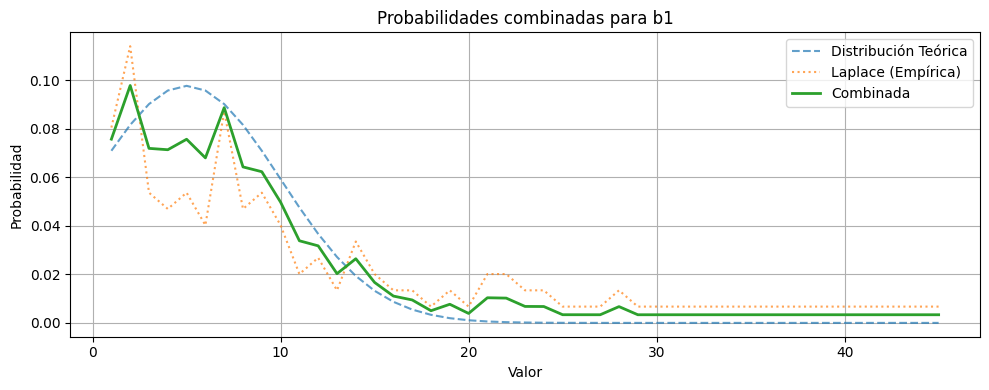

🎯 Siguientes valores más probables para b1:
  2: 0.0979
  7: 0.0887
  1: 0.0758
  5: 0.0757
  3: 0.0720
  4: 0.0714
  6: 0.0680
  8: 0.0643
  9: 0.0623
  10: 0.0498


In [24]:
b1_vals = next_gen_analyze("b1", body_size=104)

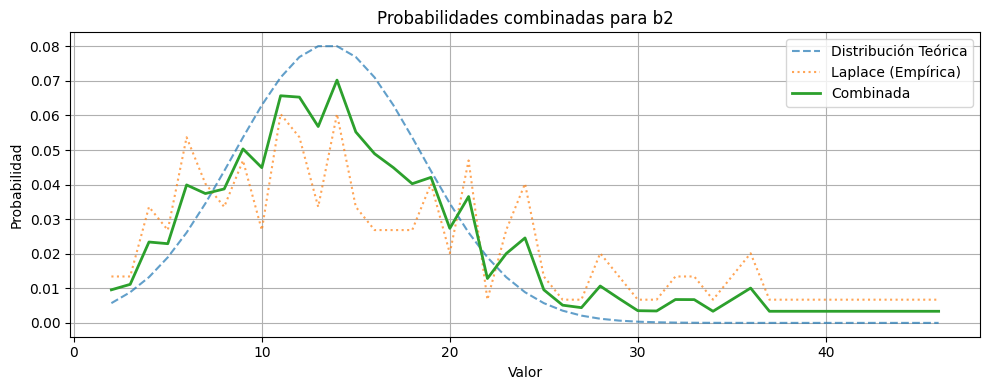

🎯 Siguientes valores más probables para b2:
  14: 0.0702
  11: 0.0657
  12: 0.0653
  13: 0.0568
  15: 0.0552
  9: 0.0503
  16: 0.0489
  10: 0.0449
  17: 0.0449
  19: 0.0421


In [25]:
b2_vals = next_gen_analyze("b2", body_size=104)

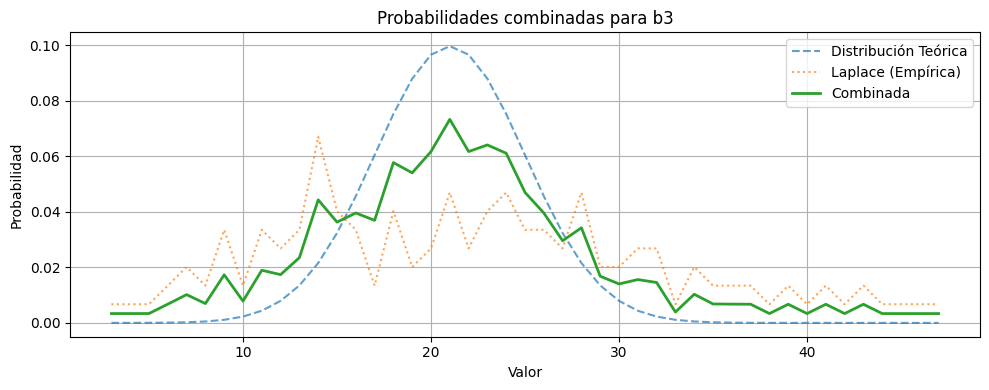

🎯 Siguientes valores más probables para b3:
  21: 0.0734
  23: 0.0641
  20: 0.0618
  22: 0.0618
  24: 0.0611
  18: 0.0578
  19: 0.0541
  25: 0.0470
  14: 0.0443
  16: 0.0396


In [26]:
b3_vals = next_gen_analyze("b3", body_size=104)

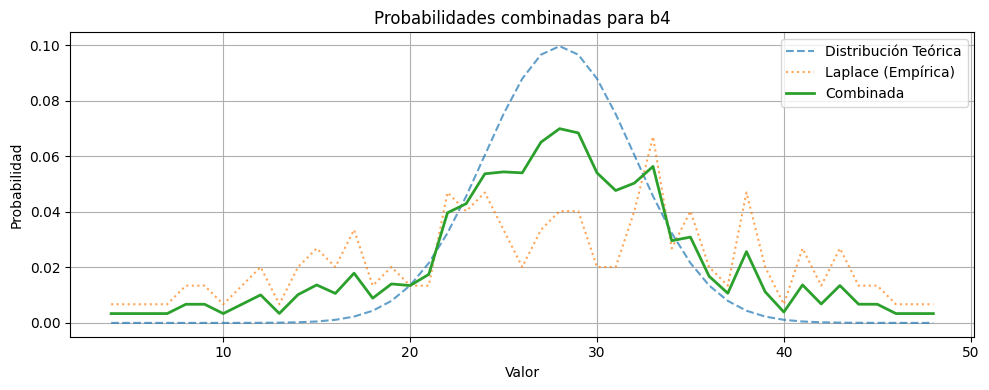

🎯 Siguientes valores más probables para b4:
  28: 0.0700
  29: 0.0685
  27: 0.0651
  33: 0.0564
  25: 0.0544
  26: 0.0541
  30: 0.0541
  24: 0.0537
  32: 0.0504
  31: 0.0477


In [27]:
b4_vals = next_gen_analyze("b4", body_size=104)

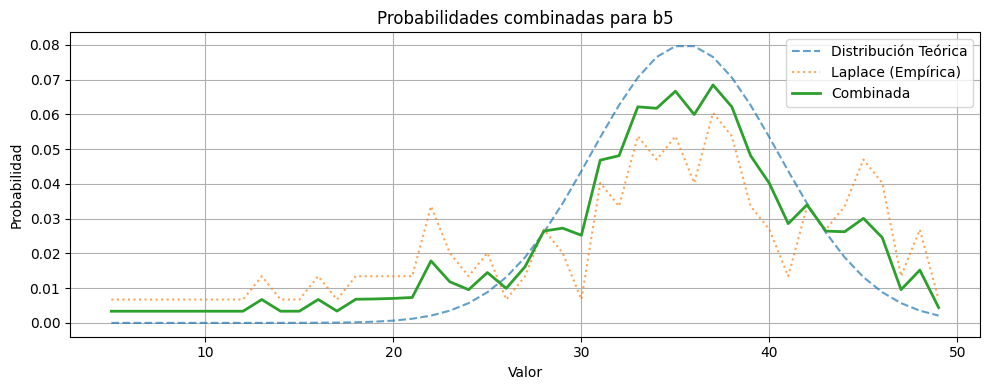

🎯 Siguientes valores más probables para b5:
  37: 0.0684
  35: 0.0666
  33: 0.0621
  38: 0.0621
  34: 0.0617
  36: 0.0599
  32: 0.0481
  39: 0.0481
  31: 0.0468
  40: 0.0401


In [28]:
b5_vals = next_gen_analyze("b5", body_size=104)

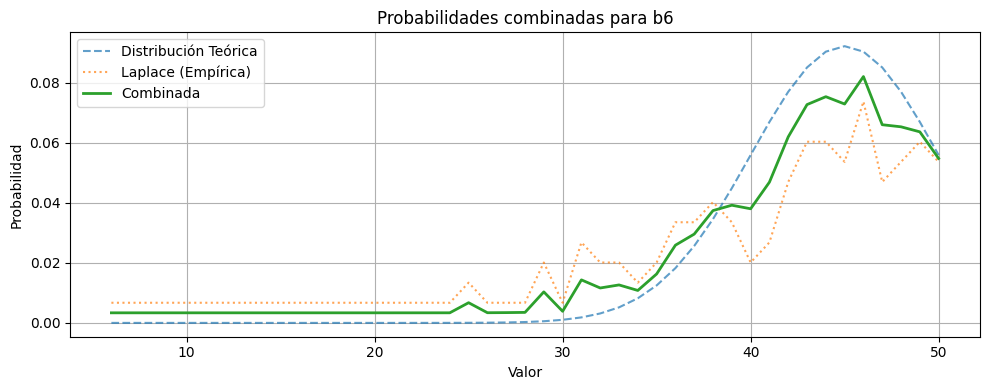

🎯 Siguientes valores más probables para b6:
  46: 0.0821
  44: 0.0754
  45: 0.0730
  43: 0.0728
  47: 0.0661
  48: 0.0654
  49: 0.0637
  42: 0.0620
  50: 0.0548
  41: 0.0469


In [29]:
b6_vals = next_gen_analyze("b6", body_size=104)